In [ ]:
import pandas as pd

# Main churn + emotion + RL dataset
df = pd.read_csv("/content/telecom_combined_3000.csv")

# Interaction dataset for recommendation system
interactions = pd.read_csv("/content/telecom_interactions_3000.csv")

# Quick check
print("Main dataset shape:", df.shape)
print("Interaction dataset shape:", interactions.shape)

df.head(), interactions.head()

Main dataset shape: (2998, 15)
Interaction dataset shape: (25000, 6)


(   customer_id  tenure_months  monthly_spend  usage_hours  inactive_days  \
 0            1             52          53.33        189.5             35   
 1            2             15          97.87        123.8             18   
 2            3             61          55.09        198.4              5   
 3            4             21          66.57        212.5             24   
 4            5             24          77.48         42.0             30   
 
    support_tickets  payment_failures  plan_changes  feedback_score  \
 0                0                 0             3            2.57   
 1                1                 0             1            4.81   
 2                1                 2             1            4.70   
 3                5                 0             4            3.64   
 4                0                 1             1            1.04   
 
    usage_trend  spend_trend  churned  avg_interaction_score  \
 0        -0.88        -0.20        1       

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# Optional but recommended
from xgboost import XGBClassifier


# Load main dataset


df = pd.read_csv("/content/telecom_combined_3000.csv")

X = df.drop(["customer_id", "churned", "favorite_category"], axis=1)
y = df["churned"]


# Train/Test split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)


# Define models


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=600, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}


# Train + Evaluate


for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n{name}")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))


Logistic Regression
Accuracy : 0.9933
Precision: 0.9932
Recall   : 0.9932
F1 Score : 0.9932

Random Forest
Accuracy : 0.9733
Precision: 0.9635
Recall   : 0.9831
F1 Score : 0.9732

Extra Trees
Accuracy : 0.9717
Precision: 0.9664
Recall   : 0.9763
F1 Score : 0.9713

Gradient Boosting
Accuracy : 0.985
Precision: 0.9864
Recall   : 0.9831
F1 Score : 0.9847

XGBoost
Accuracy : 0.9817
Precision: 0.9797
Recall   : 0.9831
F1 Score : 0.9814


In [ ]:
import numpy as np


# Emotion Score Calculation


df["emotion_score"] = (
    df["feedback_score"]
    - df["support_tickets"] * 0.5
    - df["inactive_days"] * 0.02
    + df["usage_trend"] * 1.5
)


# Emotion State Classification


def emotion_label(score):
    if score < 1.5:
        return "Angry"
    elif score < 2.5:
        return "Frustrated"
    elif score < 3.5:
        return "Neutral"
    else:
        return "Happy"

df["emotion_state"] = df["emotion_score"].apply(emotion_label)


# Emotion-Score-Based Retention Strategy


def retention_action(row):
    score = row["emotion_score"]

    if score < 1.5:
        return "Immediate call + discount"      # very angry

    elif score < 2.5:
        return "Priority support"               # frustrated

    elif score < 3.5:
        return "Engagement offers"              # neutral

    else:
        return "Upsell + loyalty"               # happy

df["retention_strategy"] = df.apply(retention_action, axis=1)


# Preview


df[["customer_id","emotion_score","emotion_state","retention_strategy"]].head(15)

,customer_id,emotion_score,emotion_state,retention_strategy
0,1,0.550,Angry,Immediate call + discount
1,2,6.965,Happy,Upsell + loyalty
2,3,5.345,Happy,Upsell + loyalty
3,4,1.485,Angry,Immediate call + discount
4,5,1.940,Frustrated,Priority support
5,6,1.300,Angry,Immediate call + discount
6,7,5.355,Happy,Upsell + loyalty
7,8,4.110,Happy,Upsell + loyalty
8,9,0.510,Angry,Immediate call + discount
9,10,2.760,Neutral,Engagement offers


In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


# Load interaction data


interactions = pd.read_csv("/content/telecom_interactions_3000.csv")


# Build user-item matrix


user_item = interactions.pivot_table(
    index="customer_id",
    columns="category",
    values="interaction_score",
    fill_value=0
)


# Compute similarity between users


similarity = cosine_similarity(user_item)

sim_df = pd.DataFrame(
    similarity,
    index=user_item.index,
    columns=user_item.index
)


# Recommendation function


def recommend_services(customer_id, top_n=3):
    similar_users = sim_df[customer_id].sort_values(ascending=False)[1:6]
    weighted_scores = user_item.loc[similar_users.index].T.dot(similar_users)
    return weighted_scores.sort_values(ascending=False).head(top_n)


# Test


recommend_services(20)

,0
category,
Insurance,18.229764
OTT Bundle,8.287301
Data Pack,1.949988


In [ ]:
import numpy as np

# Generate churn probability
best_model = models["Logistic Regression"]
df["churn_prob"] = best_model.predict_proba(X)[:,1]

def risk_bucket(p):
    if p < 0.3:
        return 0   # low
    elif p < 0.6:
        return 1   # medium
    else:
        return 2   # high

df["risk_state"] = df["churn_prob"].apply(risk_bucket)

emotion_to_int = {
    "Angry": 0,
    "Frustrated": 1,
    "Neutral": 2,
    "Happy": 3
}

df["emotion_id"] = df["emotion_state"].map(emotion_to_int)
df["rl_state"] = df["risk_state"] * 4 + df["emotion_id"]

n_states = 12
ACTIONS = [
    "do_nothing",
    "give_discount",
    "priority_support",
    "personalized_upgrade",
    "loyalty_reward"
]
n_actions = len(ACTIONS)

def reward_function(before, after):
    churn_gain = before["churn_prob"] - after["churn_prob"]
    emotion_gain = after["emotion_score"] - before["emotion_score"]
    return 0.8 * churn_gain + 0.25 * emotion_gain


import random

def simulate_action(row, action_id):
    row = row.copy()

    # chance that action actually works
    success = np.random.rand() < 0.45   # 45% success rate

    if not success:
        return row   # action failed — no improvement

    if action_id == 1:   # discount
        row["churn_prob"] *= 0.65

    elif action_id == 2:  # support
        row["emotion_score"] += 0.9
        row["churn_prob"] *= 0.75

    elif action_id == 3:  # upgrade
        row["usage_trend"] += 0.5
        row["churn_prob"] *= 0.70

    elif action_id == 4:  # reward
        row["emotion_score"] += 1.1
        row["churn_prob"] *= 0.75

    return row

Q = np.zeros((n_states, n_actions))

alpha = 0.1
gamma = 0.95
epsilon = 0.12

def choose_action(state):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

episodes = 10000

for _ in range(episodes):
    user = df.sample(1).iloc[0]

    state = int(user["rl_state"])
    action_id = choose_action(state)

    new_user = simulate_action(user, action_id)

    reward = reward_function(user, new_user)

    Q[state, action_id] += alpha * (
        reward + gamma * np.max(Q[state]) - Q[state, action_id]
    )
policy = {state: ACTIONS[np.argmax(Q[state])] for state in range(n_states)}

def full_ai_decision(customer_id):
    user = df[df["customer_id"] == customer_id].iloc[0]

    state = int(user["rl_state"])
    best_action = ACTIONS[np.argmax(Q[state])]

    print("\nCustomer:", customer_id)
    print("Churn Probability:", round(user["churn_prob"],3))
    print("Emotion:", user["emotion_state"])
    print("AI Retention Action:", best_action)

    print("\n Recommended Services:")
    print(recommend_services(customer_id))

full_ai_decision(22)


Customer: 22
Churn Probability: 0.959
Emotion: Frustrated
AI Retention Action: loyalty_reward

 Recommended Services:
category
OTT Bundle    19.846490
Insurance      9.108462
Roaming        2.472436
dtype: float64


In [ ]:
df["email"] = df["customer_id"].apply(lambda x: f"customer{x}@telecom.com")
df.loc[df["customer_id"] == 1, "email"] = "atharva.17429@sakec.ac.in"
df.loc[df["customer_id"] == 3, "email"] = "pragati.17267@sakec.ac.in"
df.loc[df["customer_id"] == 5, "email"] = "mahek.bhanushali17601@sakec.ac.in"
df.loc[df["customer_id"] == 10, "email"] = "sujal.nadvisekar18601@sakec.ac.in"
df[df["customer_id"].isin([1,3,5,10])][["customer_id","email"]]

,customer_id,email
0,1,atharva.17429@sakec.ac.in
2,3,pragati.17267@sakec.ac.in
4,5,mahek.bhanushali17601@sakec.ac.in
9,10,sujal.nadvisekar18601@sakec.ac.in


In [ ]:
import smtplib
from email.message import EmailMessage

EMAIL_ADDRESS = "kadamatharva4234@gmail.com"
EMAIL_PASSWORD = "dovc rsbf eugo mlxf"

def send_email(to_email, subject, body):
    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = to_email
    msg["Subject"] = subject
    msg.set_content(body)

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
        server.login(EMAIL_ADDRESS, EMAIL_PASSWORD)
        server.send_message(msg)
class CRMSystem:

    def get_email(self, customer_id):
        return df.loc[df["customer_id"] == customer_id, "email"].values[0]

    def send_discount_offer(self, customer_id):
        email = self.get_email(customer_id)

        subject = "🎁 Exclusive Retention Offer – Save Big on Your Telecom Plan!"

        body = f"""
Dear Valued Customer,

We truly appreciate having you as part of our telecom family.
To thank you for your continued trust, we are excited to offer you an exclusive limited-time retention benefit!

✨ YOUR SPECIAL OFFER ✨
✔ Flat 25% discount on your next monthly bill
✔ Bonus high-speed data pack absolutely FREE
✔ Priority customer support for 30 days

🚀 Why stay with us?
• Faster and more reliable network coverage
• Premium entertainment bundles
• Affordable plans customized just for you

📅 Hurry! This offer is valid for the next 7 days only.

Simply continue using our services and enjoy the savings automatically applied to your account.

Warm regards,
Customer Experience Team
Smart Telecom Services
📞 24/7 Support | 🌐 www.smarttelecom.com
"""

        send_email(email, subject, body)

    def send_support_message(self, customer_id):
        email = self.get_email(customer_id)

        subject = "We’re Here to Help – Priority Support Activated"

        body = f"""
Dear Customer,

Your satisfaction is our priority.

We noticed you may have experienced some service issues.
Our dedicated support team has created a priority service ticket just for you.

🔧 What happens next?
• A support agent will contact you within 24 hours
• Faster issue resolution
• Personalized assistance

Thank you for your patience.

Best regards,
Smart Telecom Support Team
"""

        send_email(email, subject, body)

    def send_upgrade_offer(self, customer_id):
        email = self.get_email(customer_id)

        subject = "🚀 Unlock a Faster Plan – Personalized Upgrade Available!"

        body = f"""
Hello!

We have exciting news for you!

Based on your usage, we’ve created a personalized high-speed plan upgrade that gives:

⚡ Faster internet speeds
📺 Premium OTT subscriptions
💸 Discounted upgrade pricing

Upgrade today and enjoy a better telecom experience.

Best wishes,
Smart Telecom Upgrades Team
"""

        send_email(email, subject, body)

    def send_loyalty_reward(self, customer_id):
        email = self.get_email(customer_id)

        subject = "🎉 Loyalty Rewards Added to Your Account!"

        body = f"""
Dear Customer,

Thank you for staying with Smart Telecom!

🎁 We’ve added loyalty reward points to your account which can be redeemed for:

• Bill discounts
• Free data packs
• Exclusive offers

We value your loyalty.

Warm regards,
Smart Telecom Rewards Team
"""

        send_email(email, subject, body)

    def monitor(self, customer_id):
        print("CRM monitoring – no email sent")
crm = CRMSystem()

def execute_crm_action(customer_id, action):

    if action == "give_discount":
        crm.send_discount_offer(customer_id)

    elif action == "priority_support":
        crm.send_support_message(customer_id)

    elif action == "personalized_upgrade":
        crm.send_upgrade_offer(customer_id)

    elif action == "loyalty_reward":
        crm.send_loyalty_reward(customer_id)

    else:
        crm.monitor(customer_id)
def full_ai_crm_decision(customer_id):
    user = df[df["customer_id"] == customer_id].iloc[0]

    state = int(user["rl_state"])
    action = ACTIONS[np.argmax(Q[state])]

    print("\nCustomer:", customer_id)
    print("Churn Probability:", round(user["churn_prob"],3))
    print("Emotion:", user["emotion_state"])
    print("AI Retention Action:", action)

    print("\n Recommended Services:")
    print(recommend_services(customer_id))

    print("\n Sending CRM Offer Email...")
    execute_crm_action(customer_id, action)
full_ai_crm_decision(1)
full_ai_crm_decision(3)
full_ai_crm_decision(5)
full_ai_crm_decision(10)


Customer: 1
Churn Probability: 0.96
Emotion: Angry
AI Retention Action: loyalty_reward

 Recommended Services:
category
Voice Plan    19.625063
Roaming       19.625033
OTT Bundle    16.531890
dtype: float64

 Sending CRM Offer Email...

Customer: 3
Churn Probability: 0.0
Emotion: Happy
AI Retention Action: priority_support

 Recommended Services:
category
Insurance    22.835307
Data Pack    18.531694
Roaming      12.902138
dtype: float64

 Sending CRM Offer Email...

Customer: 5
Churn Probability: 0.0
Emotion: Frustrated
AI Retention Action: priority_support

 Recommended Services:
category
Voice Plan    21.527108
OTT Bundle    13.820410
Roaming       10.181618
dtype: float64

 Sending CRM Offer Email...

Customer: 10
Churn Probability: 1.0
Emotion: Neutral
AI Retention Action: loyalty_reward

 Recommended Services:
category
Roaming       20.858199
Insurance     19.617263
Voice Plan    19.202533
dtype: float64

 Sending CRM Offer Email...


In [ ]:
df["churn_after_ai"] = df.apply(
    lambda row: simulate_action(row, np.argmax(Q[int(row["rl_state"])]) )["churn_prob"],
    axis=1
)
churn_threshold = 0.5

# Customers at risk BEFORE AI
likely_churners = df[df["churn_prob"] > churn_threshold]

# Of those churners, who improved after AI
retained = likely_churners[
    likely_churners["churn_after_ai"] < likely_churners["churn_prob"]
]

num_churners = len(likely_churners)
num_retained = len(retained)

print("Likely churners:", num_churners)
print("Customers retained:", num_retained)
print("Retention success rate:", round(num_retained / num_churners * 100, 2), "%")

# Revenue impact (realistic)
monthly_saved = retained["monthly_spend"].sum()
annual_saved = monthly_saved * 12

print(" Monthly revenue saved:", round(monthly_saved,2))
print(" Annual revenue saved:", round(annual_saved,2))

Likely churners: 1476
Customers retained: 695
Retention success rate: 47.09 %
💰 Monthly revenue saved: 42253.33
🚀 Annual revenue saved: 507039.96


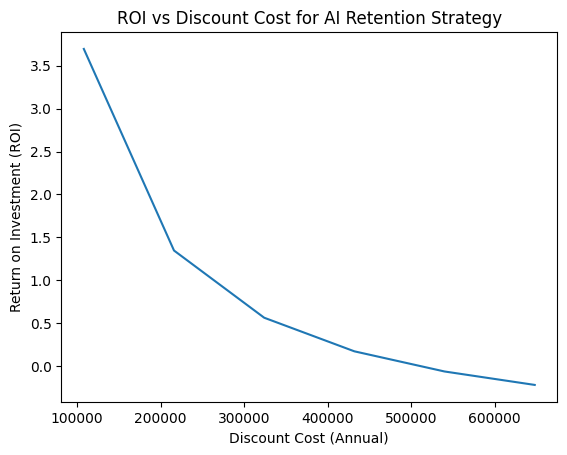

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your annual revenue saved from AI retention system
annual_saved =  507039.96

# Discount percentages to test
discount_rates = np.array([5, 10, 15, 20, 25, 30]) / 100

# Approx total yearly revenue (customers × avg spend × months)
total_revenue_base = 3000 * 60 * 12

# Annual discount cost
discount_costs = total_revenue_base * discount_rates

# ROI calculation
roi = (annual_saved - discount_costs) / discount_costs

# Plot
plt.figure()
plt.plot(discount_costs, roi)
plt.xlabel("Discount Cost (Annual)")
plt.ylabel("Return on Investment (ROI)")
plt.title("ROI vs Discount Cost for AI Retention Strategy")
plt.show()